In [1]:
model_slug = "Phi-3.5-mini-instruct"

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load .pt file
data = torch.load(f"elicit-beliefs-{model_slug}.pt", weights_only=False)
logits = data["logits"]
top_other_logit = data["top_other_logit"]
top_other_id = data["top_other_id"]
top_other_token = data["top_other_token"]

In [3]:
from supporting_code import WORDS, YES, NO, TRUE, FALSE, PROMPT_TEMPLATES, logits_to_affirm_prob, present_results

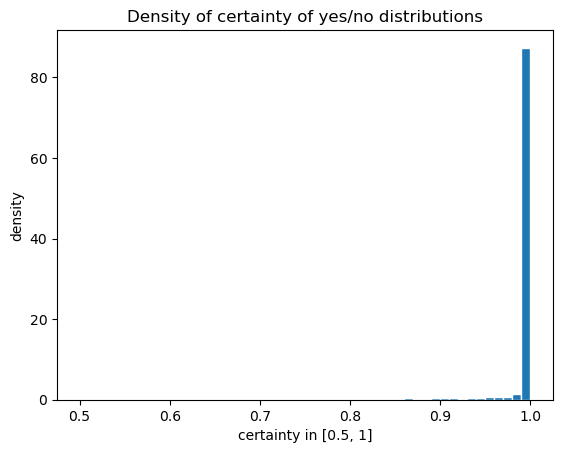

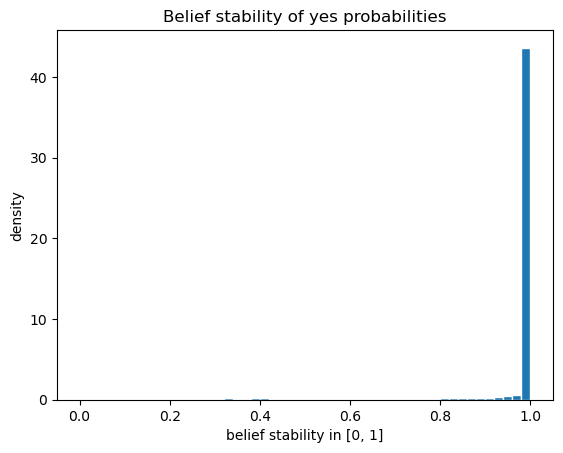

In [4]:
p_affirm = logits_to_affirm_prob(logits, prompts=[0, 1, 2, 3])
present_results(p_affirm)

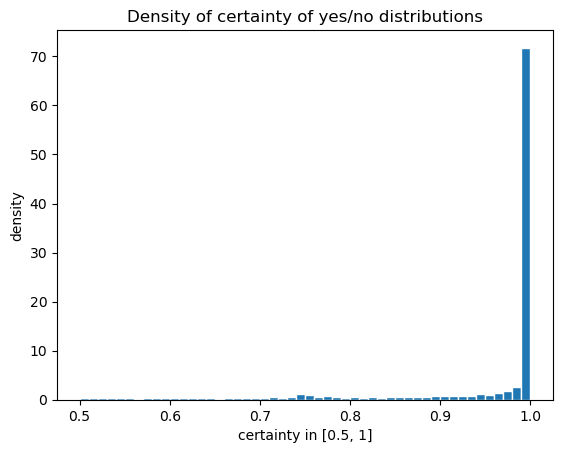

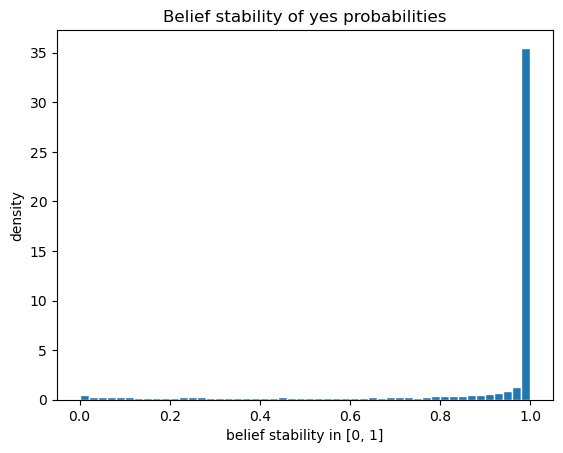

In [5]:
p_affirm = logits_to_affirm_prob(logits, prompts=[4, 5, 6, 7])
present_results(p_affirm)

In [6]:
all_logits = torch.hstack((logits, top_other_logit[:,None]))
all_probs = all_logits.softmax(axis=1)

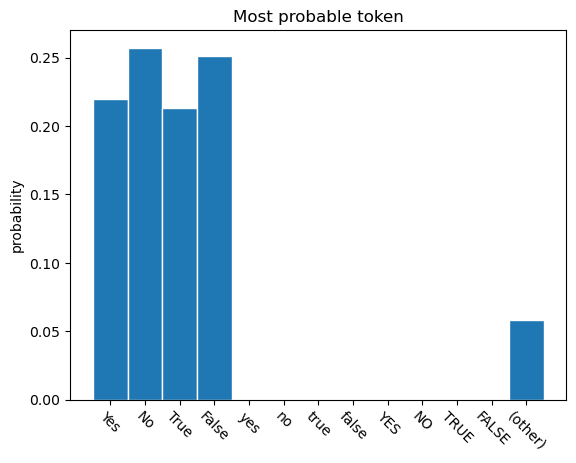

In [7]:
plt.title("Most probable token")
plt.hist(all_probs.argmax(dim=1), bins=np.arange(len(WORDS)+2) - 0.5, edgecolor='white', density=True)
plt.xticks(np.arange(len(WORDS)+1), WORDS + ["(other)"], rotation=-45)
plt.ylabel('probability')
plt.show()

In [8]:
# Most probable other token
from collections import Counter
Counter(top_other_token)

Counter({'The': 66075,
         'I': 9478,
         'Yes': 5356,
         'Correct': 4120,
         'Without': 3608,
         'Indeed': 2301,
         'Answer': 1218,
         'There': 1146,
         'That': 1071,
         'Both': 998,
         'Based': 958,
         'While': 438,
         'To': 359,
         'B': 250,
         '': 229,
         '-': 186,
         'K': 172,
         'H': 160,
         'C': 146,
         'Al': 142,
         'M': 136,
         'John': 131,
         'In': 128,
         'T': 125,
         'A': 122,
         'San': 119,
         'Ch': 117,
         'S': 113,
         'G': 112,
         'Charles': 111,
         'Sh': 110,
         'Y': 104,
         'This': 99,
         'China': 92,
         'J': 91,
         'L': 90,
         'Joseph': 90,
         'Human': 88,
         'D': 88,
         'Z': 86,
         'Port': 85,
         'N': 81,
         'Not': 79,
         'R': 77,
         'O': 76,
         'Santa': 74,
         'P': 74,
         'Gu': 74,
         

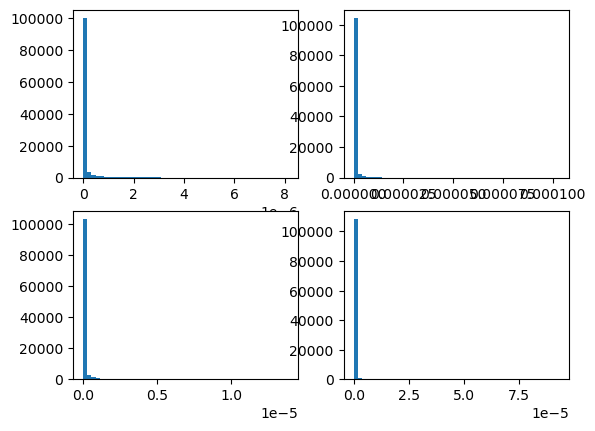

In [9]:
# histogram of yes/Yes, no/No, true/True, false/False
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.hist(all_probs[:, i+4] / all_probs[:, i], bins=50);
plt.show()

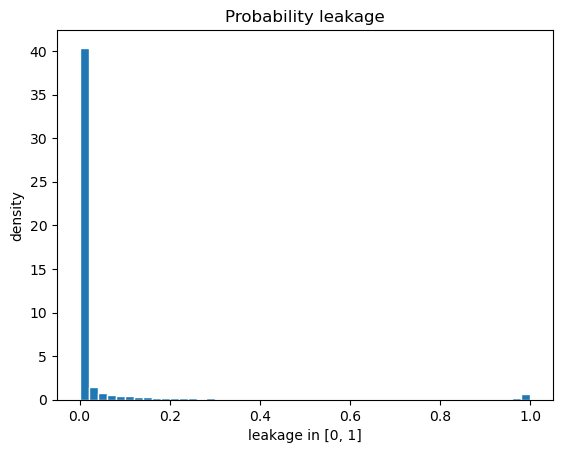

In [10]:
leakage = all_probs[:,-1]

plt.figure()
plt.title("Probability leakage")
plt.hist(leakage, bins=np.linspace(0, 1, 51), density=True, edgecolor="white")
plt.xlabel("leakage in [0, 1]")
plt.ylabel("density")

plt.show()

In [11]:
# Most probable token is other, what is it?
other_wins = (all_probs.argmax(axis=1) == len(WORDS)).argwhere()
Counter([top_other_token[i] for i in other_wins])

Counter({'I': 3255,
         'Without': 1563,
         'The': 1149,
         'There': 35,
         'Carl': 16,
         'Charles': 11,
         'Ralph': 9,
         'Santa': 8,
         'Hi': 7,
         'Mar': 5,
         'F': 5,
         'James': 5,
         'Hu': 5,
         'Hans': 5,
         'J': 4,
         'Rio': 4,
         'Gust': 4,
         'Joseph': 4,
         'Jam': 4,
         'Luther': 4,
         'Total': 4,
         'Mach': 4,
         'H': 4,
         'Br': 4,
         'Ern': 4,
         'Robert': 3,
         'United': 3,
         'Carlos': 3,
         'K': 3,
         'George': 3,
         'S': 3,
         'Lin': 3,
         'St': 3,
         'G': 3,
         'Gold': 3,
         'Y': 3,
         'Rudolf': 3,
         'Car': 3,
         'L': 3,
         'Georges': 3,
         'Tor': 2,
         'Pak': 2,
         'Epis': 2,
         'Ku': 2,
         'X': 2,
         'Eug': 2,
         'Arthur': 2,
         'Ale': 2,
         'Mars': 2,
         'West': 2,
         